In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [ ]:
class RateCalculations:
    def __init__(self, mass_DM, q_val, omega_list,omega_threshold,s_factor,):
        c = 2.998e5 #in km/s
        self.mass_DM = mass_DM
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        self.q_val = q_val
        self.omega_list = omega_list 
        self.s_factor = s_factor
        self.omega_threshold = omega_threshold # detector threshold. keV
        self.cross_section = 1e-42 # cm^2
        self.v_max = self.v_esc + self.v_earth 

    def get_v_min(self, mass_DM, q,):

        return self.omega_list/ q + q / (2 * mass_DM)
    
    def _inverse_mean_sol1(self, v_min):
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) # 1904.07915 eqn 108
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self,v_min): 
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral


    def get_inverse_mean_func(self,mass_DM, q,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min(mass_DM, q)
        return np.where(v_min>(self.v_esc+self.v_earth), 0, 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))
    
    
    def _get_omega_mask(self,):
        omega_max = self.q_val * self.v_max - self.q_val**2 / (2 * self.mass_DM)
        return (self.omega_list > self.omega_threshold) & (self.omega_list < omega_max)

    
    def get_diff_rate_dRdq(self, ): # 2108.03239 eqn 11
        reducedMass = self.mass_DM * self.mass_proton/(self.mass_DM + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM * reducedMass**2)
        omega_mask = self._get_omega_mask()
        if np.sum(omega_mask)<2: 
            return 0.
        else:
            integrand = self.get_inverse_mean_func(self.mass_DM,self.q_val) * self.s_factor * self.q_val
            return constFactor * sp.integrate.simpson(integrand[omega_mask], self.omega_list[omega_mask])


    def get_cross_section(self, ): 
        return 3/self.scattering_rate # 3 evt per kg per year


Isotropic rate:
$ R = \frac{1}{\rho_T}\frac{\rho_\chi}{m_\chi}\int \frac{q\,dq}{(2\pi)^2}d\omega\,\eta(v_{min}(q,\omega))\times\frac{\pi\bar\sigma(q)}{\mu^2\chi}\times S(q,\omega) $

Differential rate: 
$ \frac{dR}{dq} = \frac{1}{\rho_T}\frac{\rho_\chi}{m_\chi}\frac{\pi\bar\sigma(q)}{\mu^2\chi}\frac{q}{(2\pi)^2}\int d\omega\,\eta(v_{min}(q,\omega))\times S(q,\omega) $

In [3]:
def get_impulse_approx_multi(q_min=0.004, q_max=200., omega_th=10e-6, omega_max=0.12, omega_bar=30e-6, xlength=1000, ylength=1000): # all in keV
    ''' 
    2d impulse approx with shape (# of q, # of omega)
    '''
    omglist = np.linspace(omega_th, omega_max,xlength)
    qlist = np.linspace(q_min, q_max,ylength) # keV
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3

    deltasq = qlist[:, np.newaxis]**2 * omega_bar/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omglist[np.newaxis, :]-(qlist[:, np.newaxis]**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


In [4]:
def get_impulse_approx(q, omega_th=10e-6, omega_max=0.12, xlength=1000, omega_bar=30e-6, ):
    omglist = np.linspace(omega_th, omega_max,xlength)
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_bar/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omglist-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


$$q_\pm \equiv m_\chi v \bigg(1\pm \sqrt{1-\frac{2\omega_{th}}{m_\chi v^2}}\bigg) $$
$$\omega_+ \equiv qv -\frac{q^2}{2m_\chi}$$

In [5]:
def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q, omega_threshold=10e-6): 
    v_max = 0.00247 # in c
    return omega_threshold, q * v_max - q**2 / (2 * mass_DM)


In [6]:
dm_length = 200
dmmasslist = 10**np.linspace(3, 6, dm_length) # keV, = 1MeV ~ 1GeV
omega_threshold = 10e-6 # keV

In [7]:
rate_result = np.empty(dm_length)
for ind_m, dmmass in enumerate(dmmasslist):
    omega_length=1000
    q_length=1000
    qlist = np.linspace(*get_q_lim(dmmass, omega_threshold), q_length)
    dRdq_result = np.empty(q_length)
    if ind_m%10 == 0: print(f'processing {ind_m}...')
    for ind_q, q in enumerate(qlist): 
        omega_max = get_omega_lim(dmmass, q, omega_threshold)
        omegalist = np.linspace(omega_threshold,omega_max , omega_length)
        s_factor_ia = get_impulse_approx(q, omega_threshold, omega_max,omega_length, omega_bar=30e-6,)
        rateCal = RateCalculations(dmmass, q, omegalist, omega_threshold, s_factor_ia)
        dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
    if (dmmass>39e3) & (dmmass<40e3):
        dRdq_4plot = dRdq_result
        qlist_4plot = qlist
        dmmass_4plot = dmmass
    rate_result[ind_m] = sp.integrate.simpson(dRdq_result, qlist)
    

processing 0...
processing 10...
processing 20...
processing 30...
processing 40...
processing 50...
processing 60...
processing 70...
processing 80...
processing 90...
processing 100...
processing 110...
processing 120...
processing 130...
processing 140...
processing 150...
processing 160...
processing 170...
processing 180...
processing 190...


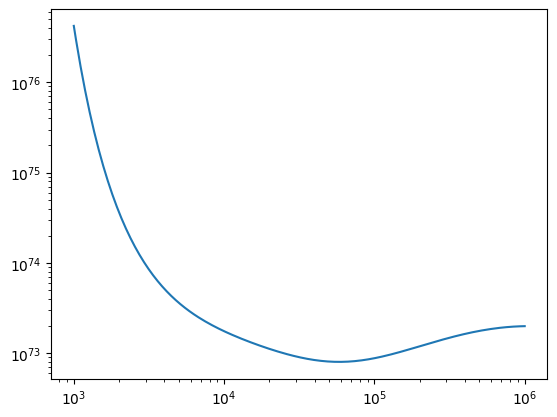

In [8]:
# plt.plot(qlist_4plot, dRdq_4plot)
# plt.plot(dmmasslist,rate_result)
plt.plot(dmmasslist, 3/rate_result)
plt.yscale('log')
plt.xscale('log')

(1e-200, 1e-70)

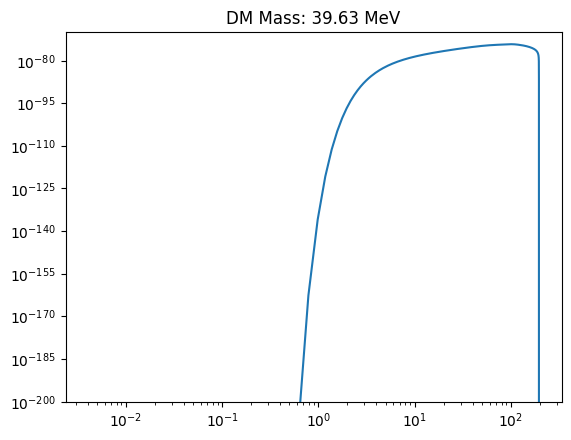

In [14]:
plt.plot(qlist_4plot, dRdq_4plot)
plt.title(f'DM Mass: {dmmass_4plot/1e3:.2f} MeV')
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-200,1e-70)

In [ ]:
eVtoInvS = 1.5192674e15 # eV to 1/s
yeartosec=86400 * 365.
eVtoInvYr = eVtoInvS * yeartosec
eVtokg=1.78e-36